# Defects and Surface Analysis of h-BN and Silicon

This notebook investigates crystal defects and surface structures in h-BN and Silicon.

The notebook focuses on:
- vacancy defect generation
- surface slab creation
- structural visualization
- defect interpretation

Defects and surfaces play important roles in:
- semiconductor physics
- catalysis
- nanotechnology
- electronic materials

In [1]:
from pymatgen.core.structure import Structure
from pymatgen.io.ase import AseAtomsAdaptor

from pymatgen.core.surface import SlabGenerator

from ase.visualize import view

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
## loading the data

hbn = Structure.from_file("..\\data\\h-BN.cif")

si = Structure.from_file("..\\data\\sillicon.cif")

c:\Users\Admin\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3112: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


# Vacancy Defects

Real crystalline materials are rarely perfect.

Vacancy defects occur when atoms are missing from their normal lattice positions.

Defects strongly influence:
- conductivity
- diffusion
- mechanical behavior
- electronic properties
- semiconductor performance

In [3]:
## hBN vacancy

hbn_defect = hbn.copy()

hbn_defect.remove_sites([0])

print(hbn_defect)

Full Formula (B1 N2)
Reduced Formula: BN2
abc   :   2.510000   2.510000   6.690000
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (3)
  #  SP           a         b     c
---  ----  --------  --------  ----
  0  B3+   0.666667  0.333333  0.95
  1  N3-   0         0         0
  2  N3-   0         0         0.5


In [4]:
## silicon vacancy

si_defect = si.copy()
si_defect.remove_sites([0])


print("Silicon vacancy:")
print(si_defect)

Silicon vacancy:
Full Formula (Si7)
Reduced Formula: Si
abc   :   5.430700   5.430700   5.430700
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (7)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Si    0     0.5   0.5
  1  Si    0.5   0     0.5
  2  Si    0.5   0.5   0
  3  Si    0.75  0.75  0.25
  4  Si    0.75  0.25  0.75
  5  Si    0.25  0.75  0.75
  6  Si    0.25  0.25  0.25


In [5]:
## visualization

adaptor = AseAtomsAdaptor()

hbn_defect_ase = adaptor.get_atoms(hbn_defect)

si_defect_ase = adaptor.get_atoms(si_defect)

In [6]:
view(hbn_defect_ase)

<Popen: returncode: None args: ['c:\\Users\\Admin\\anaconda3\\python.exe', '...>

In [7]:
view(si_defect_ase)

<Popen: returncode: None args: ['c:\\Users\\Admin\\anaconda3\\python.exe', '...>

# Surface and Slab Structures

Surface structures are created by cutting crystals along specific crystallographic directions.

Surface analysis is important in:
- catalysis
- adsorption studies
- nanomaterials
- semiconductor devices

A slab model represents a finite crystal surface with vacuum spacing.

In [8]:
## generate silicon (100) surface

slab_gen = SlabGenerator(
    initial_structure=si,
    miller_index=(1, 0, 0),
    min_slab_size=10,
    min_vacuum_size=10,
)

In [9]:
## create the slab

si_slab = slab_gen.get_slab()

print(si_slab)

Slab Summary (Si8)
Reduced Formula: Si
Miller index: (1, 0, 0)
Shift: 0.0000, Scale Factor: [[0 1 0]
 [0 0 1]
 [1 0 0]]
abc   :   3.840085   3.840085  21.722800
angles:  90.000000  90.000000  90.000000
Sites (8)
1 Si     1.000000     0.000000     1.000000
2 Si     0.500000     0.500000     0.875000
3 Si     0.000000     0.500000     0.812500
4 Si     0.500000     0.000000     0.937500
5 Si     1.000000     0.000000     0.750000
6 Si     0.500000     0.500000     0.625000
7 Si     0.000000     0.500000     0.562500
8 Si     0.500000     0.000000     0.687500


In [10]:
## Visualize the slab

si_slab_ase = adaptor.get_atoms(si_slab)

view(si_slab_ase)

<Popen: returncode: None args: ['c:\\Users\\Admin\\anaconda3\\python.exe', '...>

In [11]:
## Comparing the atoms numbers

comparison = {
    "Structure": [
        "Original h-BN",
        "Defective h-BN",
        "Original Silicon",
        "Defective Silicon"
    ],

    "Atoms": [
        len(hbn),
        len(hbn_defect),
        len(si),
        len(si_defect)
    ]
}

df = pd.DataFrame(comparison)

df

,Structure,Atoms
0,Original h-BN,4
1,Defective h-BN,3
2,Original Silicon,8
3,Defective Silicon,7


# Structural Effects of Defects

Vacancy defects modify:
- local bonding environments
- crystal symmetry
- coordination behavior
- atomic periodicity

Defects are essential in understanding real material behavior because they strongly influence electronic and mechanical properties.

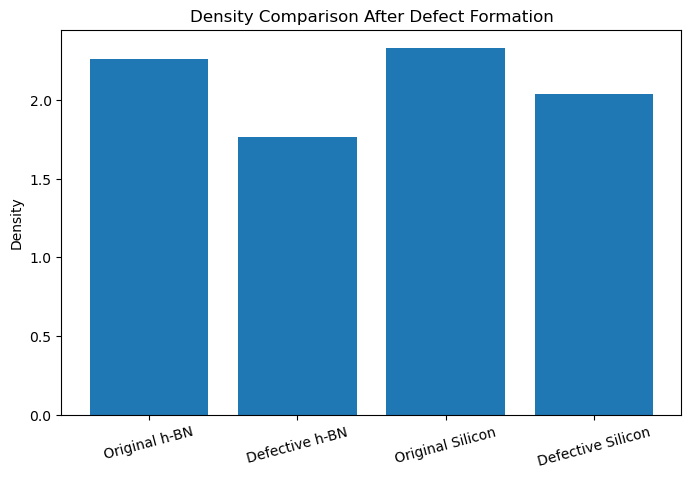

In [12]:
## Density comparison

materials = [
    "Original h-BN",
    "Defective h-BN",
    "Original Silicon",
    "Defective Silicon"
]

densities = [
    hbn.density,
    hbn_defect.density,
    si.density,
    si_defect.density
]

plt.figure(figsize=(8,5))

plt.bar(materials, densities)

plt.xticks(rotation=15)

plt.ylabel("Density")

plt.title("Density Comparison After Defect Formation")

plt.show()

# Interpretation

The defect structures exhibit reduced structural symmetry due to missing atomic sites.

Vacancy formation alters local atomic environments and breaks perfect crystal periodicity.

Surface slab generation demonstrates how finite crystal surfaces differ from bulk periodic structures.

These analyses are highly relevant in computational materials science because real materials often contain defects and exposed surfaces.